# Pipeline latency

Where the time goes in a single `/v1/search` call, stage by stage:

```
text → GLiNER NER → char-n-gram BM25 → hydration → CatBoost reranker
```

**Measured on the real code path, not a reimplementation.** `SearchEngine.search`
already logs each stage's wall time; this notebook attaches a log handler and
parses those lines. So the numbers are what the served pipeline actually did —
adding a stage to the engine makes it appear here without touching this file.

Runs in process: no server, no database. Needs `data/artifacts/` (`make artifacts`
or `make hub-pull`) and the NER checkpoint.

In [1]:
import logging, os, re, statistics, sys, time
from pathlib import Path

# Run from the repository root, not notebooks/: every path in `src.config` is
# relative to it (`data/artifacts`, `data/golden_set.parquet`), so this is what
# makes the notebook see the same files the CLI does.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from src.config import settings
from src.search.engine import SearchEngine

QUERIES = pl.read_parquet(settings.rerank.golden_set_path)["query"].to_list()
print(f"running from {ROOT}")
print(f"{len(QUERIES)} queries from the golden set")

running from /home/kseniia/geosearch
235 queries from the golden set


## Capturing the stages

Each stage logs `"<Stage>: %.3fs …"`. One handler, one regex — the engine stays
untouched, and a stage renamed there shows up as a missing key here rather than
as a silently wrong total.

In [2]:
STAGE_LINE = re.compile(r"^(NER|Retrieval|Hydration|Reranker|Total): ([0-9.]+)s")

# The reranker logs which path it took. Worth keeping: "(retriever-score order)"
# means no model was loaded, and then the "Reranker" row is not measuring a model.
RERANK_MODE = re.compile(r"^Reranker: [0-9.]+s \((.+)\)")


class StageCollector(logging.Handler):
    """Collect per-stage timings from the engine's own log lines."""

    def __init__(self):
        super().__init__(level=logging.INFO)
        self.rows: list[dict] = []
        self._current: dict = {}
        self.rerank_modes: set[str] = set()

    def emit(self, record):
        message = record.getMessage()
        match = STAGE_LINE.match(message)
        if not match:
            return
        stage, seconds = match.group(1), float(match.group(2))
        if mode := RERANK_MODE.match(message):
            self.rerank_modes.add(mode.group(1))
        self._current[stage] = seconds * 1000  # ms
        if stage == "Total":
            self.rows.append(self._current)
            self._current = {}


collector = StageCollector()
engine_logger = logging.getLogger("src.search.engine")
engine_logger.setLevel(logging.INFO)
engine_logger.addHandler(collector)
engine_logger.propagate = False  # keep the per-query lines out of the notebook

## Cold start

What a process pays once, before it can answer anything. On a HuggingFace Space
this is the whole cold-start cost, and it is paid again after every idle
shutdown — there is no persistent storage on the free tier.

In [3]:
# `await`, not `asyncio.run`: the kernel already runs an event loop, and
# IPython supports top-level await.
t0 = time.perf_counter()
engine = await SearchEngine.build(settings)
cold_start_s = time.perf_counter() - t0
print(f"engine built in {cold_start_s:.1f}s")

engine built in 10.3s


## Per-query timings

The golden set twice: reranker off, then on. The difference isolates what the
reranker costs, since retrieval and NER are identical between the two.

In [4]:
async def run(queries, *, use_rerank):
    collector.rows.clear()
    t0 = time.perf_counter()
    for q in queries:
        await engine.search(q, top_k=50, use_rerank=use_rerank)
    elapsed = time.perf_counter() - t0
    return pl.DataFrame(collector.rows), elapsed


off, off_wall = await run(QUERIES, use_rerank=False)
on, on_wall = await run(QUERIES, use_rerank=True)

print(f"reranker off: {len(off)} queries in {off_wall:.1f}s")
print(f"reranker on : {len(on)} queries in {on_wall:.1f}s")
print("reranker path(s) taken:", collector.rerank_modes)

reranker off: 235 queries in 87.4s
reranker on : 235 queries in 97.7s
reranker path(s) taken: {'model', 'retriever-score order'}


> A `retriever-score order` above means **no reranker model was loaded** — the
> `Reranker` row is then measuring a sort, not a model, and the two runs will
> look identical. Check `data/rerank_model.cbm` exists if that is unexpected.

## Headline numbers

In [5]:
STAGES = ["NER", "Retrieval", "Hydration", "Reranker"]


def pct(series, q):
    return statistics.quantiles(series, n=100)[q - 1] if len(series) > 2 else max(series)


def values(frame, stage):
    """Timings for one stage, minus the queries that never reached it.

    A query whose NER found no spans returns before retrieval, and one that
    retrieved nothing returns before hydration — those rows carry a null for the
    stages they skipped. Dropping them is right: averaging a stage over queries
    that never ran it would understate it.
    """
    return frame[stage].drop_nulls().to_list()


short_circuited = len(on) - len(values(on, "Reranker"))
total = values(on, "Total")
median_total, p95_total = statistics.median(total), pct(total, 95)

print(f"median   {median_total:7.0f} ms   ({1000 / median_total:.1f} queries/s single-threaded)")
print(f"p95      {p95_total:7.0f} ms")
print(f"max      {max(total):7.0f} ms")
print(f"cold start {cold_start_s:5.1f} s   (~{cold_start_s * 1000 / median_total:.0f} queries' worth)")
if short_circuited:
    print("")
    print(f"{short_circuited}/{len(on)} queries returned early — NER found no spans,")
    print("so nothing was retrieved. Excluded per stage, not from Total.")

median       393 ms   (2.5 queries/s single-threaded)
p95          628 ms
max         1405 ms
cold start  10.3 s   (~26 queries' worth)

43/235 queries returned early — NER found no spans,
so nothing was retrieved. Excluded per stage, not from Total.


## Where the time goes

Magnitude comparison across four named stages, so: horizontal bars, one hue.
Median and p95 as two shades of the same hue rather than two colors — they are
two quantiles of one measure, not two different things.

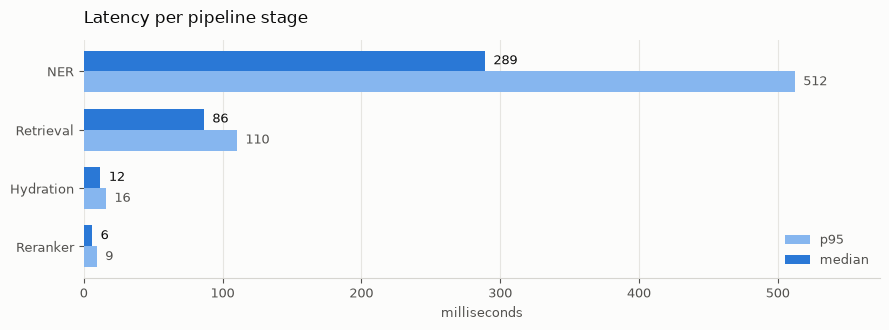

In [6]:
# Reference palette (references/palette.md), light surface.
BLUE_450, BLUE_250 = "#2a78d6", "#86b6ef"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

summary = pl.DataFrame(
    {
        "stage": STAGES,
        "median": [statistics.median(values(on, s)) for s in STAGES],
        "p95": [pct(values(on, s), 95) for s in STAGES],
    }
).sort("median", descending=True)

fig, ax = plt.subplots(figsize=(9, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
y = range(len(summary))
h = 0.36

ax.barh([i + h / 2 for i in y], summary["p95"], height=h, color=BLUE_250, label="p95")
ax.barh([i - h / 2 for i in y], summary["median"], height=h, color=BLUE_450, label="median")

# Direct labels: mandatory once two series share the plot.
for i, (m, p) in enumerate(zip(summary["median"], summary["p95"])):
    ax.text(m + max(summary["p95"]) * 0.012, i - h / 2, f"{m:.0f}", va="center",
            fontsize=9, color=INK)
    ax.text(p + max(summary["p95"]) * 0.012, i + h / 2, f"{p:.0f}", va="center",
            fontsize=9, color=INK_MUTED)

ax.set_yticks(list(y), summary["stage"], fontsize=10, color=INK)
ax.invert_yaxis()
ax.set_xlabel("milliseconds", fontsize=9, color=INK_MUTED)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}"))
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="x", color="#e6e5e1", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d6d5d0")
ax.set_xlim(0, max(summary["p95"]) * 1.12)
ax.legend(frameon=False, fontsize=9, labelcolor=INK_MUTED, loc="lower right")
ax.set_title("Latency per pipeline stage", fontsize=12, color=INK, loc="left", pad=12)
plt.tight_layout()
plt.show()

The same numbers as a table — the chart shows the shape, the table is what you
quote. `share` is of the summed stage medians, not of `Total`: the two differ by
the orchestration between stages.

In [7]:
share = summary.with_columns(
    (pl.col("median") / pl.col("median").sum() * 100).round(1).alias("share_%")
)
print(share)
print(f"\nsum of stage medians: {summary['median'].sum():.0f} ms")
print(f"median Total:         {median_total:.0f} ms")

shape: (4, 4)
┌───────────┬────────┬────────┬─────────┐
│ stage     ┆ median ┆ p95    ┆ share_% │
│ ---       ┆ ---    ┆ ---    ┆ ---     │
│ str       ┆ f64    ┆ f64    ┆ f64     │
╞═══════════╪════════╪════════╪═════════╡
│ NER       ┆ 289.0  ┆ 512.2  ┆ 73.4    │
│ Retrieval ┆ 86.5   ┆ 110.35 ┆ 22.0    │
│ Hydration ┆ 12.0   ┆ 16.0   ┆ 3.0     │
│ Reranker  ┆ 6.0    ┆ 9.35   ┆ 1.5     │
└───────────┴────────┴────────┴─────────┘

sum of stage medians: 394 ms
median Total:         393 ms


## How much does the reranker cost?

Retrieval and NER do identical work in both runs, so the difference is the
reranker's price — worth knowing against what it buys (P@1 0.85 → 0.88, RR
0.887 → 0.922 on the golden set; see `make rerank-eval`).

In [8]:
delta = pl.DataFrame(
    {
        "stage": STAGES + ["Total"],
        "off_ms": [round(statistics.median(values(off, s)), 1) for s in STAGES + ["Total"]],
        "on_ms": [round(statistics.median(values(on, s)), 1) for s in STAGES + ["Total"]],
    }
).with_columns((pl.col("on_ms") - pl.col("off_ms")).round(1).alias("delta_ms"))
print(delta)

shape: (5, 4)
┌───────────┬────────┬───────┬──────────┐
│ stage     ┆ off_ms ┆ on_ms ┆ delta_ms │
│ ---       ┆ ---    ┆ ---   ┆ ---      │
│ str       ┆ f64    ┆ f64   ┆ f64      │
╞═══════════╪════════╪═══════╪══════════╡
│ NER       ┆ 247.0  ┆ 289.0 ┆ 42.0     │
│ Retrieval ┆ 104.0  ┆ 86.5  ┆ -17.5    │
│ Hydration ┆ 12.0   ┆ 12.0  ┆ 0.0      │
│ Reranker  ┆ 0.0    ┆ 6.0   ┆ 6.0      │
│ Total     ┆ 363.0  ┆ 393.0 ┆ 30.0     │
└───────────┴────────┴───────┴──────────┘


## Distribution of total latency

One series, so no legend — the title names it. A histogram rather than a bar
chart: the question here is spread, not comparison between named things.

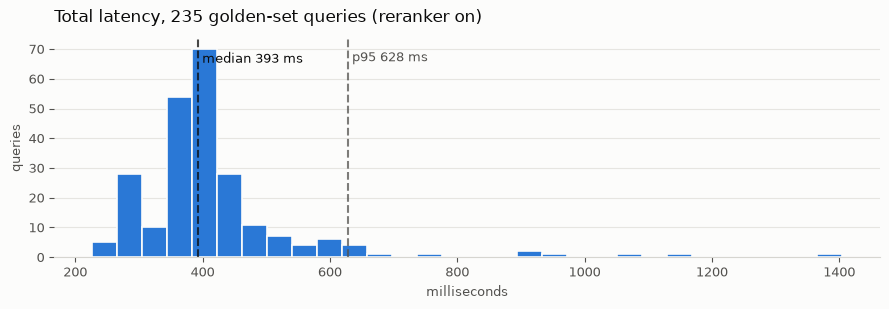

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.hist(total, bins=30, color=BLUE_450, edgecolor=SURFACE, linewidth=1.2)
for value, label, color in [(median_total, "median", INK), (p95_total, "p95", INK_MUTED)]:
    ax.axvline(value, color=color, linewidth=1.5, linestyle="--", alpha=0.75)
    ax.text(value, ax.get_ylim()[1] * 0.94, f" {label} {value:.0f} ms",
            fontsize=9, color=color, va="top")

ax.set_xlabel("milliseconds", fontsize=9, color=INK_MUTED)
ax.set_ylabel("queries", fontsize=9, color=INK_MUTED)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color="#e6e5e1", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#d6d5d0")
ax.set_title(f"Total latency, {len(total)} golden-set queries (reranker on)",
             fontsize=12, color=INK, loc="left", pad=12)
plt.tight_layout()
plt.show()

## Full percentiles

In [10]:
rows = []
for stage in STAGES + ["Total"]:
    xs = sorted(values(on, stage))
    rows.append({
        "stage": stage,
        "min": round(xs[0], 1),
        "p50": round(statistics.median(xs), 1),
        "p90": round(pct(xs, 90), 1),
        "p95": round(pct(xs, 95), 1),
        "p99": round(pct(xs, 99), 1),
        "max": round(xs[-1], 1),
    })
print(pl.DataFrame(rows))

shape: (5, 7)
┌───────────┬───────┬───────┬───────┬───────┬────────┬────────┐
│ stage     ┆ min   ┆ p50   ┆ p90   ┆ p95   ┆ p99    ┆ max    │
│ ---       ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---    ┆ ---    │
│ str       ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64    ┆ f64    │
╞═══════════╪═══════╪═══════╪═══════╪═══════╪════════╪════════╡
│ NER       ┆ 207.0 ┆ 289.0 ┆ 423.0 ┆ 512.2 ┆ 1069.2 ┆ 1287.0 │
│ Retrieval ┆ 68.0  ┆ 86.5  ┆ 108.0 ┆ 110.3 ┆ 145.9  ┆ 158.0  │
│ Hydration ┆ 6.0   ┆ 12.0  ┆ 15.0  ┆ 16.0  ┆ 20.2   ┆ 23.0   │
│ Reranker  ┆ 4.0   ┆ 6.0   ┆ 8.7   ┆ 9.3   ┆ 15.9   ┆ 41.0   │
│ Total     ┆ 226.0 ┆ 393.0 ┆ 539.4 ┆ 628.4 ┆ 1131.4 ┆ 1405.0 │
└───────────┴───────┴───────┴───────┴───────┴────────┴────────┘


## Reading these numbers

**NER dominates: ~73% of a request.** GLiNER is a 278M-parameter mDeBERTa-v3, and
on CPU a short query costs ~290 ms median, ~512 ms p95. If throughput ever
matters this is the first thing to attack — ONNX export or quantisation, which is
what stage 7 of the project plan is for.

**Retrieval is ~87 ms, and 99% of that is a sort, not the search.** Measured
separately: `BM25Index.get_scores` over 1.19M documents takes **0.8 ms** — the CSR
rewrite did its job — but `get_top_n` then calls `np.argsort` on all 1.19M scores
to take 50, which costs **80 ms**. `np.argpartition` returns the same top-50 in
**5 ms**.

That is a real ~16x on this stage, but it is not a free swap: `argsort` and
`argpartition` can order *ties* differently, and BM25 ties are the common case
here — every homonym under one name shares a score. Changing it needs the same
treatment the CSR rewrite got: assert the retrieved set and its order are
unchanged over the golden set before believing the speedup. Until then this is a
measurement, not a fix.

**Hydration (~12 ms) is a Parquet semi-join,** not a database round trip. It
scales with `top_k`, not with the 1.3M-row table, so it stays flat as the corpus
grows.

**The reranker costs ~6 ms** — 1.5% of a request, for P@1 0.85 → 0.88 and RR
0.887 → 0.922 on the golden set (`make rerank-eval`). That is the cheapest stage
in the pipeline by a wide margin.

**43 of 235 golden-set queries returned early** because NER found no spans. They
are excluded from the per-stage numbers (they never ran those stages) but not
from `Total`, which is why the totals here are a little lower than the stage sums
would suggest.

## Caveats

Single-threaded, one process, warm caches, this machine — the *proportions* are
the point, the absolute numbers are not portable. The off/on comparison also
shows ±40 ms of run-to-run drift on NER, which does identical work in both runs;
read the `delta_ms` column as "roughly the reranker's 6 ms," not as four
significant figures. And the golden set is 235 short queries: a long query costs
more NER, not more retrieval.